# Escuchar música generada
Reproduce los archivos MIDI generados por el modelo.

In [29]:
import os
import pygame
import time
import pretty_midi
import matplotlib.pyplot as plt


In [30]:
# Cambia a True si corres en Google Colab
COLAB = False

if COLAB:
    GENERATED_DIR = '/content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated'
else:
    GENERATED_DIR = './generated'

print(f'Carpeta de MIDIs: {GENERATED_DIR}')
print('Archivos disponibles:')
for f in sorted(os.listdir(GENERATED_DIR)):
    if f.endswith('.mid'):
        print(f'  {f}')


Carpeta de MIDIs: ./generated
Archivos disponibles:
  beethoven_1_4_topk_5.mid
  beethoven_bs100_hand1.mid
  beethoven_combined.mid
  beethoven_gen_1.mid
  beethoven_gen_1_5.mid
  beethoven_gen_1_good_1_2.mid
  beethoven_gen_2.mid
  beethoven_gen_2_good_1_2.mid
  beethoven_gen_3.mid
  beethoven_gen_3_good_1_2.mid
  beethoven_hand2.mid
  beethoven_topk_bs100_combined.mid
  beethoven_topk_bs100_hand1.mid
  beethoven_topk_hand1.mid
  beethoven_topk_hand2.mid


In [31]:
def play_midi(filepath, seconds=15):
    """Reproduce un archivo MIDI durante 'seconds' segundos."""
    pygame.mixer.init()
    pygame.mixer.music.load(filepath)
    pygame.mixer.music.play()
    print(f'Reproduciendo: {os.path.basename(filepath)} ({seconds}s)...')
    time.sleep(seconds)
    pygame.mixer.music.stop()
    print('Listo.')


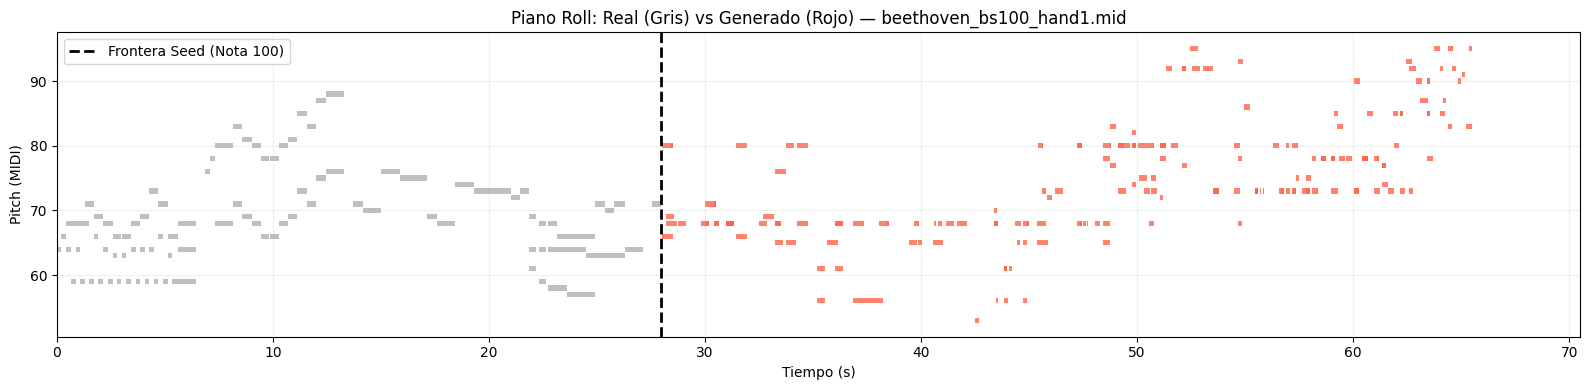

Notas Reales (Seed): 100
Notas Generadas:     200
El "Beethoven IA" empezó a componer en el segundo: 27.97s


In [32]:
# --- Piano roll con división Real vs Generado ---
MIDI_NUM = 1
midi_path = os.path.join(GENERATED_DIR, f'/Users/sebastian/Library/Mobile Documents/com~apple~CloudDocs/Maestria Andes/Tercer semestre/Natural Language Processing 2/MAIA_NLP_2/Microproyectos/Microproyecto_1/Sebastian/generated/beethoven_bs100_hand1.mid')

pm = pretty_midi.PrettyMIDI(midi_path)
notes = sorted(pm.instruments[0].notes, key=lambda n: n.start)

# Definimos el límite basado en tu BLOCK_SIZE
SEED_LIMIT = 100  # Notas 0 a 63 son reales

fig, ax = plt.subplots(figsize=(16, 4))

for i, note in enumerate(notes):
    # Diferenciamos color: Gris para lo real, Tomate para lo generado
    color = 'gray' if i < SEED_LIMIT else 'tomato'
    alpha = 0.5 if i < SEED_LIMIT else 0.8
    
    ax.barh(note.pitch, note.end - note.start, left=note.start,
            height=0.8, color=color, alpha=alpha)
    
    # Marcamos el tiempo exacto donde termina el seed
    if i == SEED_LIMIT - 1:
        time_boundary = note.end

# Línea vertical divisoria
ax.axvline(time_boundary, color='black', linestyle='--', linewidth=2, 
           label=f'Frontera Seed (Nota {SEED_LIMIT})')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Pitch (MIDI)')
ax.set_title(f'Piano Roll: Real (Gris) vs Generado (Rojo) — beethoven_bs100_hand1.mid')
ax.set_xlim(0, pm.get_end_time() + 5) # Ajuste dinámico del tiempo
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Notas Reales (Seed): {SEED_LIMIT}')
print(f'Notas Generadas:     {len(notes) - SEED_LIMIT}')
print(f'El "Beethoven IA" empezó a componer en el segundo: {time_boundary:.2f}s')

In [33]:
# Escuchar una canción generada — cambia el número (1, 2 o 3)
play_midi(os.path.join(GENERATED_DIR, f'/Users/sebastian/Library/Mobile Documents/com~apple~CloudDocs/Maestria Andes/Tercer semestre/Natural Language Processing 2/MAIA_NLP_2/Microproyectos/Microproyecto_1/Sebastian/generated/beethoven_bs100_hand1.mid'), seconds=70)


Reproduciendo: beethoven_bs100_hand1.mid (70s)...


KeyboardInterrupt: 

In [ ]:
# import plotly.graph_objects as go
# from IPython.display import Audio, display
# import os
# import pretty_midi

# # --- Configuración ---
# MIDI_NUM = 2
# SEED_LIMIT = 64
# midi_path = os.path.join(GENERATED_DIR, f'beethoven_gen_{MIDI_NUM}.mid')

# # 1. Cargar MIDI y preparar datos
# pm = pretty_midi.PrettyMIDI(midi_path)
# notes = sorted(pm.instruments[0].notes, key=lambda n: n.start)
# time_boundary = notes[SEED_LIMIT - 1].end

# # 2. Crear la gráfica interactiva con Plotly
# fig = go.Figure()

# # Añadimos las notas una por una (o por grupos para velocidad)
# for i, note in enumerate(notes):
#     is_seed = i < SEED_LIMIT
#     fig.add_trace(go.Bar(
#         x=[note.end - note.start],
#         y=[note.pitch],
#         base=note.start,
#         orientation='h',
#         marker=dict(
#             color='lightgray' if is_seed else 'tomato',
#             line=dict(width=0.5, color='black')
#         ),
#         name='Real (Seed)' if is_seed else 'Generado',
#         showlegend=False,
#         hoverinfo='text',
#         text=f"Nota: {i} | Pitch: {note.pitch} | Inicio: {note.start:.2f}s"
#     ))

# # Línea vertical de frontera
# fig.add_vline(x=time_boundary, line_dash="dash", line_color="black", 
#               annotation_text=" Comienza IA", annotation_position="top right")

# # Configuración del diseño y Slider de tiempo
# fig.update_layout(
#     title=f"Reproductor de Beethoven IA - MIDI #{MIDI_NUM}",
#     xaxis=dict(
#         title="Tiempo (segundos)",
#         rangeslider=dict(visible=True), # AQUÍ ESTÁ EL SLIDER DINÁMICO
#         type="linear"
#     ),
#     yaxis=dict(title="Pitch (MIDI)"),
#     barmode='stack',
#     height=500,
#     plot_bgcolor='white',
#     showlegend=True
# )

# # 3. Renderizar gráfica y cargar el audio
# fig.show()

# # Convertir MIDI a audio para el reproductor (usa el sintetizador de pretty_midi)
# # .synthesize() genera una onda senoidal básica de las notas
# audio_data = pm.synthesize(fs=44100) 
# display(Audio(audio_data, rate=44100))